# Transduction sandbox

Working notebook for the Fock-state decoder (lossy-beamsplitter channel). We
append each step here.

**Phase calibration (this notebook so far):**
- **Section 1 — phi_E (encoder phase)** via cavity Wigner tomography of the
  encoded |0>+|2>. The phase of rho[2,0] is the |2>-vs-|0> phase the encoder
  imparts; we null it so `prep_fock_state` produces the *nominal* |+_L>.
- **Section 2 — phi_D (decode/readout phase)** via error-amplified round-trip
  (encode->decode)^N on |+>, azimuth-only readout. The round-trip slope gives
  phi_total = phi_E + phi_D, so phi_D = phi_total - phi_E.

Corrections compose in a small ledger: encoder gets -phi_E, readout gets -phi_D,
and later the channel contributes phi_ch(eta). Environment mode = **M1-S3**
(used from Section 3 on).


## Section 0 — setup

In [34]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from tqdm.notebook import tqdm
from pathlib import Path
import qutip as qt

import experiments as meas
from experiments.MM_dual_rail_base import MM_dual_rail_base
from experiments import MultimodeStation, CharacterizationRunner
from experiments.transduction.decoder import (
    build_encoder_seq, build_decoder_seq, revert_pulse_seq,
)
from fitting.state_tomography import state_fidelity, PX, PY, PZ
from fitting.wigner import WignerAnalysis, OptimalDisplacementGeneration

from slab import AttrDict
from job_server import JobClient
from job_server.database import get_database
from job_server.config_versioning import ConfigVersionManager

db = get_database()
config_dir = str(Path.cwd().parent.parent / 'configs')
config_manager = ConfigVersionManager(config_dir)

client = JobClient()
health = client.health_check()
print(f"Server status: {health['status']}  pending: {health['pending_jobs']}")

user = "seb"
station = MultimodeStation(
    user=user,
    experiment_name="260601_Transduction_sandbox",
    project="Transduction",
    log_measurements=True,
)
USE_QUEUE = True
mm_base_calib = MM_dual_rail_base(station.hardware_cfg, station.soccfg)

# Active reset that works for you (ge/ef + qubit-based man reset + heralding)
active_reset_dict = {
    'active_reset': True,
    'ef_reset': False,
    'storage_reset': False,
    'coupler_reset': False,
    'pre_selection_reset': True,
    'man_reset': False,
    'use_qubit_man_reset': False,
    'pre_selection_parity': True,
    'ps_threshold_sigma': -.5
}

MAN_NO = 1
ENV_STORAGE = 7   # M1-S1 environment (used from Section 3 on)
relax_delay_channel = 10000 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Server status: healthy  pending: 9
[STATION] Using main hardware_config version: CFG-HW-20260608-00050
[STATION] Using main multiphoton_config version: CFG-MP-20260121-00001
[STATION] Using main man1_storage_swap version: CFG-M1-20260608-00015
[STATION] Using main floquet_storage_swap version: CFG-FL-20260223-00024
[STATION] Lab-notebook vault: G:\Shared drives\SLab\Multimode
Data, plots, logs will be stored in: C:\experiments\260601_Transduction_sandbox
Hardware configs will be read from C:\python\multimode_expts\configs\versions\hardware_config\CFG-HW-20260608-00050.yml
dict_keys(['Pyro.NameServer', 'Qick101'])
QICK running on ZCU216, software version 0.2.291

Firmware configuration (built Tue Oct 15 12:06:51 2024):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	7 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 32768 samples (5.128 us)
		fs=6389.760 MHz, fabr

Job submitted: JOB-20260609-00124 (queue position: 9)

[0.0s] Job JOB-20260609-00124: pending

[114.8s] Job JOB-20260609-00124: running
[WORKER] Loading HistogramExperiment from experiments.single_qubit.single_shot
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260609-00124_HistogramExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 82%|███████████████████████████████████████████████████████████████████████████████████████████████▋                     | 4090/5000 [00:08<00:01, 495.77it/s]
[135.0s] Job JOB-20260609-00124: completed
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:10<00:00, 495.66it/s]
Active reset with pre-selection is enabled
PS funnel (kept per round, k_sigma=-0.5):
  prep g: 5000  ->  3853 (77%, PS g-reset)  ->  3097 (62%, PS parity)
  prep e: 5000

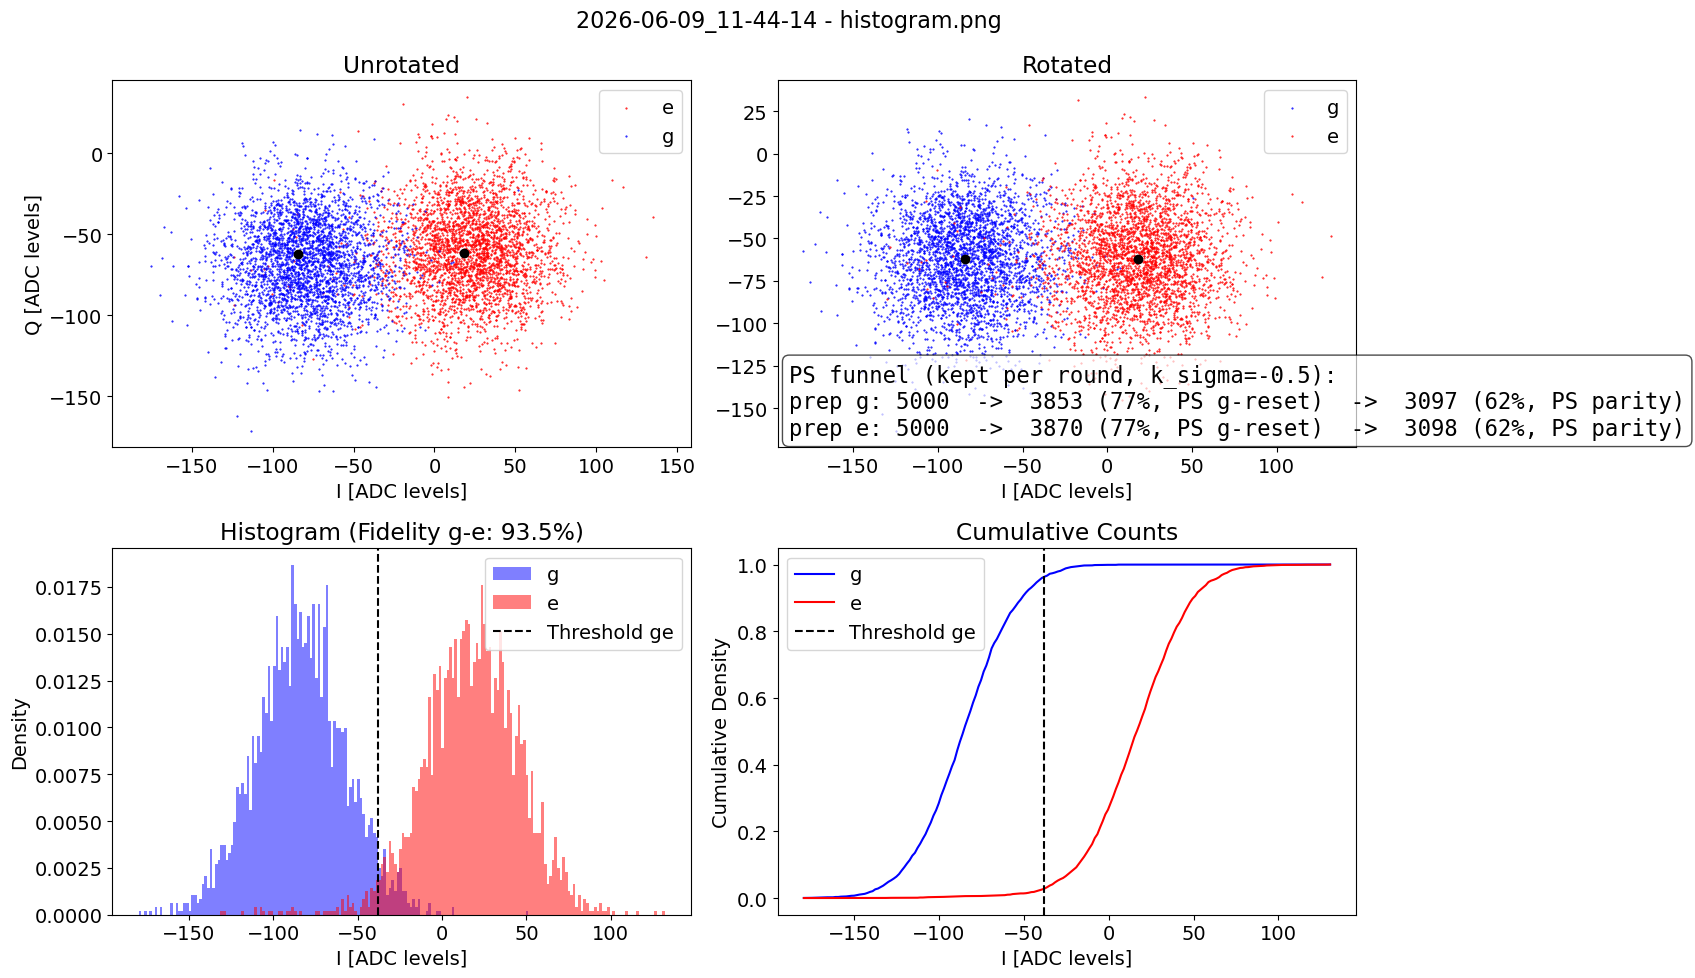

In [35]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
singleshot_defaults = AttrDict(dict(    
    reps=5000,
    relax_delay=500,
    check_f=False,
    active_reset=False,
    man_reset=False,
    storage_reset=False,
    qubit=0,
    pulse_manipulate=False,
    cavity_freq=4984.373226159381,
    cavity_gain=400,
    cavity_length=2,
    prepulse=False,
    pre_sweep_pulse=None,
    gate_based=True,
    qubits=[0],
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def singleshot_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    # add the active reset dict to the expt config so that it can be used in the postprocessor
    return expt_cfg



def singleshot_postproc(station, expt):
    expt.analyze(plot=False, station=station, subdir=station.autocalib_path)
    fids = expt.data['fids']
    confusion_matrix = expt.data['confusion_matrix']
    thresholds_new = expt.data['thresholds']
    angle = expt.data['angle']
    print(fids)

    hardware_cfg = station.hardware_cfg
    hardware_cfg.device.readout.phase = [hardware_cfg.device.readout.phase[0] + angle]
    hardware_cfg.device.readout.threshold = thresholds_new
    hardware_cfg.device.readout.threshold_list = [thresholds_new]
    hardware_cfg.device.readout.Ie = [np.median(expt.data['Ie_rot'])]
    hardware_cfg.device.readout.Ig = [np.median(expt.data['Ig_rot'])]
    if expt.cfg.expt.active_reset:
        hardware_cfg.device.readout.confusion_matrix_with_active_reset = confusion_matrix
    else:
        hardware_cfg.device.readout.confusion_matrix_without_reset = confusion_matrix
    print('Updated readout!')



single_shot_runner = CharacterizationRunner(
    station = station,
    ExptClass = meas.HistogramExperiment,
    default_expt_cfg = singleshot_defaults,
    postprocessor = singleshot_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)


single_shot = single_shot_runner.execute(
        go_kwargs=dict(analyze=False, display=False),
        check_f=False,
        relax_delay=2000,
        pre_sweep_pulse=None,
        prepulse=False,
        gate_based=False,
        reps=5000,
        **active_reset_dict,
    )

In [9]:
# --- encoder / decoder + cardinal helpers ---
E_seq = build_encoder_seq(mm_base_calib, man_no=MAN_NO)   # state-indep transduction
D_seq = build_decoder_seq(mm_base_calib, man_no=MAN_NO)   # = E^dagger

# Corrected cardinal prep phases (Phase-1 convention: ge hpi phase phi ->
# Bloch (-sin phi, -cos phi, 0)).
PREP_SEQS = {
    '0':  [], '1': [['qubit', 'ge', 'pi', 0]],
    '+':  [['qubit', 'ge', 'hpi', 270]], '-':  [['qubit', 'ge', 'hpi', 90]],
    '+i': [['qubit', 'ge', 'hpi', 180]], '-i': [['qubit', 'ge', 'hpi', 0]],
}
# logical L -> photon list for prep_fock_state, and the ideal decoded qubit ket
LOGICAL_PHOTONS = {'0': [0], '1': [2], '+': [0, 2], '-': [0, -2],
                   '+i': [0, -2j], '-i': [0, 2j]}   # swapped: hardware flips the imag sign

IDEAL_KETS = {
    '0': np.array([1, 0], dtype=complex), '1': np.array([0, 1], dtype=complex),
    '+': np.array([1, 1], dtype=complex)/np.sqrt(2),
    '-': np.array([1, -1], dtype=complex)/np.sqrt(2),
    '+i': np.array([1, 1j], dtype=complex)/np.sqrt(2),
    '-i': np.array([1, -1j], dtype=complex)/np.sqrt(2),
}

def build_logical_prep(photon_list, enc_phase_corr_deg=0.0):
    '''prep_fock_state for a logical cavity state, with the encoder phase
    correction folded into the leading superposition (g0-e0 hpi) pulse.'''
    seq = mm_base_calib.prep_fock_state(MAN_NO, photon_list, broadband=False)
    seq = [list(g) for g in seq]
    if len(photon_list) == 2 and seq and seq[0][2] == 'hpi':
        seq[0][3] = (seq[0][3] + enc_phase_corr_deg) % 360
    return seq

def bloch_vector(rho):
    return np.array([np.real(np.trace(rho @ PX)), np.real(np.trace(rho @ PY)),
                     np.real(np.trace(rho @ PZ))])
def purity(rho):
    return float(np.real(np.trace(rho @ rho)))

# phase-correction ledger (deg). Filled by Sections 1 and 2.
PHASE_LEDGER = {'encoder': 0.0, 'decoder': 0.0}

Preparing state 0 and 2 with coeff 1.0
Preparing state 0 and 2 with coeff 1.0


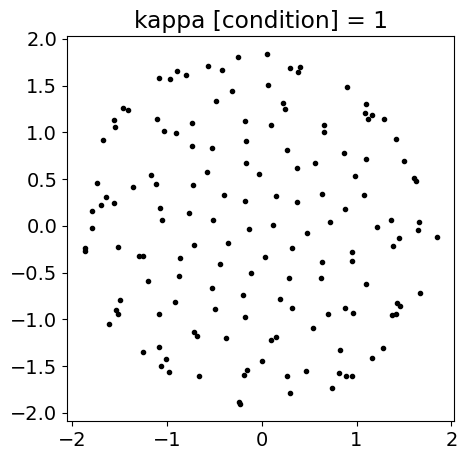

Displacements saved to C:\experiments\260601_Transduction_sandbox\optimized_displacements_23.npy


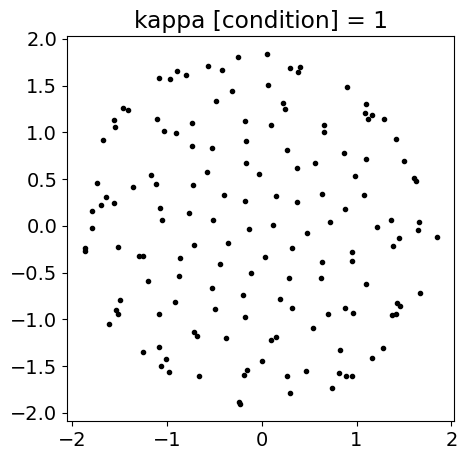

In [36]:
# --- runners ---

# Optimal displacements for Wigner tomography (one-time per session)
opt_alphas = OptimalDisplacementGeneration(FD=5, n_disps=150, objective='condition')
return_dict = opt_alphas.optimize(save_dir=station.experiment_path)

wigner_1mode_defaults = AttrDict(dict(
    displace_length=0.05, displacement_path=None, prepulse=False,
    pre_sweep_pulse=[], pre_gate_sweep_pulse=[], reps=1000, qubits=[0],
    gate_based=False, pulse_correction=True, relax_delay=2500,
    post_select_pre_pulse=False, opt_pulse=None, IQ_table=None,
    active_reset=False, parity_fast=False,
))
wigner_1mode_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.qubit_cavity.single_mode_wigner_tomography.WignerTomography1ModeExperiment,
    default_expt_cfg=wigner_1mode_defaults,
    job_client=client, use_queue=USE_QUEUE,
)


conf = station.hardware_cfg.device.readout.confusion_matrix_with_active_reset
# Tomography runner (reused for the round-trip and the decode validation)
tomo_defaults = AttrDict(dict(
    reps=200, rounds=1, qubits=[0],
    state_prep_seq=[], bases=['Z', 'X', 'Y'],
    tomo_phases={'X': 90, 'Y': 0}, recon_method='fast', relax_delay=2500,
    dedupe_waveforms=True, 
    confusion = [float(x) for x in conf]   # flows into tomo_runner AND val_runner
  # share identical envelopes -> long (E+D)^N sequences fit the gen buffer
))
tomo_defaults.update(active_reset_dict)

tomo_runner = CharacterizationRunner(
    station=station, ExptClass=meas.StateTomography1QExperiment,
    default_expt_cfg=tomo_defaults, job_client=client, use_queue=USE_QUEUE,
)

## Section 1 — encoder phase phi_E (Wigner)

Encode |0>+|2> with `build_logical_prep([0,2], corr)`, run Wigner tomography,
reconstruct rho with `rotate=False` (so the phase is NOT removed), and read
`phi_E = angle(rho[2,0])`. Set `enc_corr = -phi_E` and re-run to confirm the
coherence is real (phi_E ~ 0). One correction fixes all four equatorial logicals
(same Stark phase).

In [37]:
WIG_CUTOFF = 4
ideal_02 = (qt.basis(WIG_CUTOFF, 0) + qt.basis(WIG_CUTOFF, 2)).unit()

def measure_phi_E(enc_phase_corr_deg=0.0, reps=200, plot=True):
    prep = build_logical_prep([0, 2], enc_phase_corr_deg)
    pulse = mm_base_calib.get_prepulse_creator(
        prep, cfg=station.hardware_cfg).pulse.tolist()
    wig = wigner_1mode_runner.execute(
        displace_length=0.05, reps=reps,
        displacement_path=return_dict['path'],
        prepulse=True, pre_sweep_pulse=pulse, gate_based=False,
        pulse_correction=True, relax_delay=2500, post_select_pre_pulse=False,
        parity_fast=False,
        show=plot,
        # ideal panel = the encoded |0>+|2> (NOT Fock 0); rotate=False so the
        # phi_E tilt we're measuring shows up in the plot rather than being aligned away.
        display_kwargs=dict(initial_state=ideal_02, rotate=False,
                            mode_state_num=WIG_CUTOFF,
                            state_label=f'|0>+|2> corr={enc_phase_corr_deg:.0f}deg'),
        **active_reset_dict,
    )
    wa = WignerAnalysis(wig.data, config=wig.cfg, mode_state_num=WIG_CUTOFF,
                        alphas=wig.data['alpha'])
    res = wa.wigner_analysis_results(wig.data['parity'],
                                     initial_state=ideal_02, rotate=False)
    rho = res['rho']
    rho = rho.full() if hasattr(rho, 'full') else np.asarray(rho)
    phi_E = np.degrees(np.angle(rho[2, 0]))
    coh = np.abs(rho[2, 0])
    print(f"corr={enc_phase_corr_deg:7.2f} deg -> phi_E={phi_E:7.2f} deg, "
          f"|rho[2,0]|={coh:.3f}, pop0={np.real(rho[0,0]):.3f}, "
          f"pop2={np.real(rho[2,2]):.3f}")
    return phi_E, rho, wig

Preparing state 0 and 2 with coeff 1.0
Job submitted: JOB-20260609-00136 (queue position: 1)

[0.0s] Job JOB-20260609-00136: pending

[2.0s] Job JOB-20260609-00136: running
[WORKER] Loading WignerTomography1ModeExperiment from experiments.qubit_cavity.single_mode_wigner_tomography
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260609-00136_WignerTomography1ModeExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏| 150/151 [03:22<00:01,  1.32s/it]
[207.4s] Job JOB-20260609-00136: completed
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 151/151 [03:24<00:00,  1.35s/it]
Saving C:\experiments\260601_Transduction_sandbox\data\JOB-20260609-00136_WignerTomography

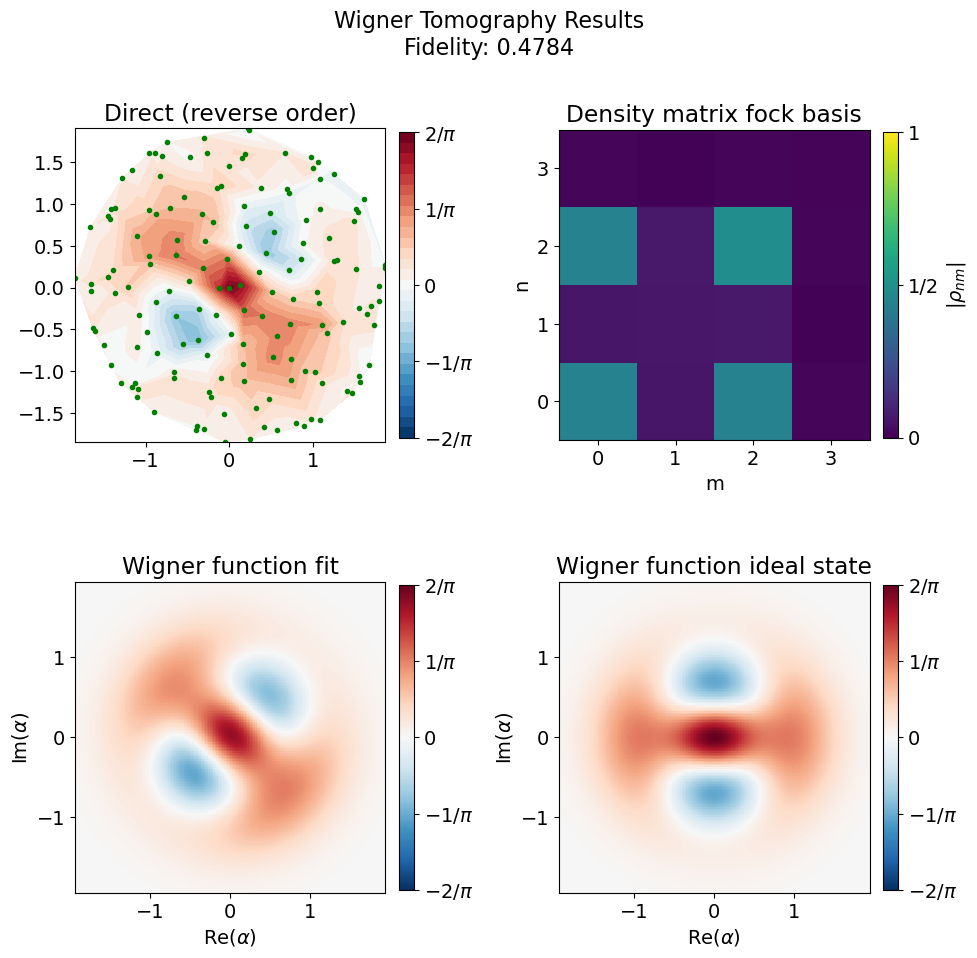

corr=   0.00 deg -> phi_E= -88.45 deg, |rho[2,0]|=0.445, pop0=0.441, pop2=0.492
Preparing state 0 and 2 with coeff 1.0
Job submitted: JOB-20260609-00148 (queue position: 11)

[0.0s] Job JOB-20260609-00148: pending

[165.1s] Job JOB-20260609-00148: running
[WORKER] Loading WignerTomography1ModeExperiment from experiments.qubit_cavity.single_mode_wigner_tomography
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260609-00148_WignerTomography1ModeExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 99%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍ | 149/151 [03:21<00:02,  1.36s/it]
[368.5s] Job JOB-20260609-00148: completed
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 151/151 [03:24<00:00,  1.35s/it]
Saving 

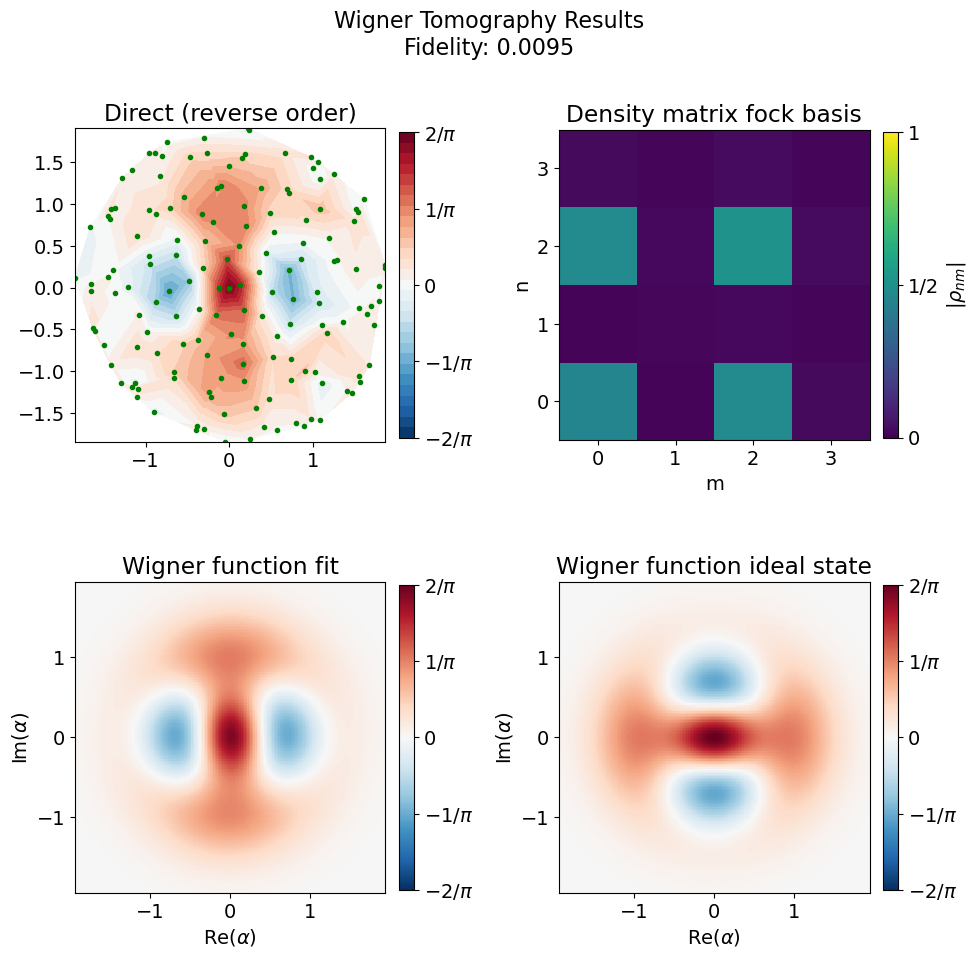

corr=  90.00 deg -> phi_E=-179.07 deg, |rho[2,0]|=0.474, pop0=0.457, pop2=0.510
slope dphi_E/dcorr = -1.007  (expect ~ -1)
raw phi_E(corr=0)  = -88.45 deg
ENCODER_PHASE_CORR = 272.16 deg


In [38]:
# Calibrate encoder phase: sweep corr, linear-fit phi_E(corr), solve for zero.
# (phi_E responds to corr with slope ~ -1, so a naive -phi_E has the wrong sign;
# the zero-crossing solve is sign-agnostic.)
corr_list = [0.0, 90.0]          # 2 points suffice (linear); add more to beat noise
phis = [measure_phi_E(c, reps=200)[0] for c in corr_list]
phis_unw = np.degrees(np.unwrap(np.radians(phis)))
slope, intercept = np.polyfit(corr_list, phis_unw, 1)

phi_E = phis[0]                                   # raw encoder phase (corr=0), used in Sec 2
ENCODER_PHASE_CORR = (-intercept / slope) % 360   # corr where phi_E -> 0
PHASE_LEDGER['encoder'] = ENCODER_PHASE_CORR
print(f"slope dphi_E/dcorr = {slope:.3f}  (expect ~ -1)")
print(f"raw phi_E(corr=0)  = {phi_E:.2f} deg")
print(f"ENCODER_PHASE_CORR = {ENCODER_PHASE_CORR:.2f} deg")

Preparing state 0 and 2 with coeff 1.0
Job submitted: JOB-20260608-00251 (queue position: 1)

[0.0s] Job JOB-20260608-00251: pending

[76.7s] Job JOB-20260608-00251: running
[WORKER] Loading WignerTomography1ModeExperiment from experiments.qubit_cavity.single_mode_wigner_tomography
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260608-00251_WignerTomography1ModeExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 99%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍ | 149/151 [03:21<00:02,  1.33s/it]
[280.6s] Job JOB-20260608-00251: completed
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 151/151 [03:23<00:00,  1.35s/it]
Saving C:\experiments\260601_Transduction_sandbox\data\JOB-20260608-00251_WignerTomograph

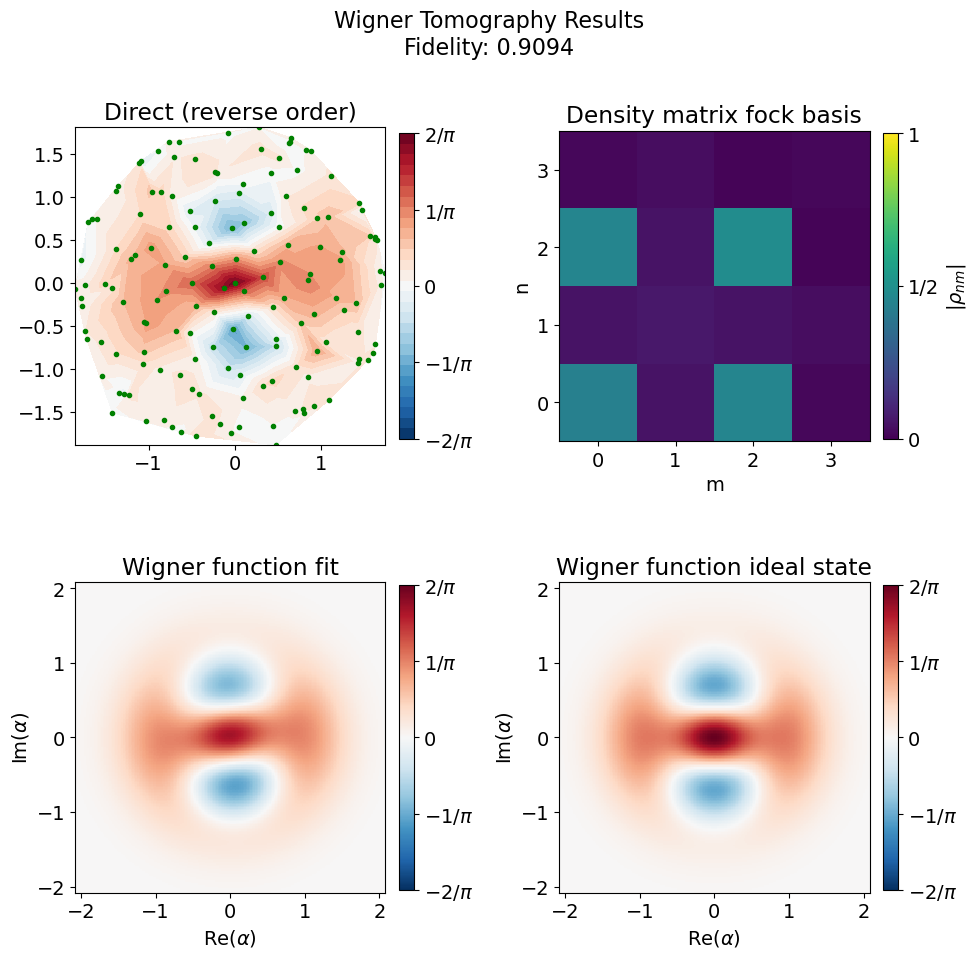

corr= 245.57 deg -> phi_E=   8.09 deg, |rho[2,0]|=0.456, pop0=0.433, pop2=0.484
residual encoder phase: 8.09 deg  (target ~0)


In [7]:
# 2) verify: with the correction the coherence should be ~real (phi_E ~ 0).
# If it overshoots, the hpi-phase -> coherence-phase sign is flipped; try +phi_E.
phi_E_chk, rho1, _ = measure_phi_E(ENCODER_PHASE_CORR, reps=200)
PHASE_LEDGER['encoder'] = ENCODER_PHASE_CORR
print('residual encoder phase:', round(phi_E_chk, 2), 'deg  (target ~0)')

## Section 2 — decode phase phi_D (error-amplified round-trip)

Apply `(E_seq + D_seq)^N` to |+>, read azimuth only (X,Y). Each round-trip adds
`phi_total = phi_E + phi_D`, so the azimuth grows linearly: slope = phi_total.
Then `phi_D = phi_total - phi_E`.

In [8]:
def roundtrip_preproc(station, default_expt_cfg, **kwargs):
    cfg = deepcopy(default_expt_cfg)
    cfg.update(kwargs)
    n = int(cfg.get('n_roundtrips', 1))
    cfg.state_prep_seq = (deepcopy(PREP_SEQS['+'])
                          + (deepcopy(E_seq) + deepcopy(D_seq)) * n)
    cfg.bases = ['X', 'Y']         # azimuth only
    return cfg

roundtrip_runner = CharacterizationRunner(
    station=station, ExptClass=meas.StateTomography1QExperiment,
    default_expt_cfg=tomo_defaults, preprocessor=roundtrip_preproc,
    job_client=client, use_queue=USE_QUEUE,
)

N_MAX = 2   # dedupe_waveforms=True lifts the old ~N=3 buffer limit
Ns = list(range(0, N_MAX + 1))
azis = []
contrasts = []
for n in tqdm(Ns, desc='round-trips'):
    e = roundtrip_runner.execute(n_roundtrips=n, reps=2000)
    e.analyze()
    azis.append(np.degrees(e.data['azimuth_rad']))
    contrasts.append(e.data['equatorial_contrast'])
azis = np.array(azis); contrasts = np.array(contrasts)
print('azimuth(deg) vs N:', np.round(azis, 1))
print('contrast    vs N:', np.round(contrasts, 3))

round-trips:   0%|          | 0/3 [00:00<?, ?it/s]

Job submitted: JOB-20260608-00253 (queue position: 1)

[0.0s] Job JOB-20260608-00253: pending

[75.8s] Job JOB-20260608-00253: running
[WORKER] Loading StateTomography1QExperiment from experiments.single_qubit.state_tomography_1q
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260608-00253_StateTomography1QExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 55%|███████████████████████████████████████████████████████████████▉                                                     | 1092/2000 [00:02<00:02, 397.30it/s]
[85.9s] Job JOB-20260608-00253: completed
basis: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:10<00:00,  5.46s/it]
Bases measured: ['X', 'Y'] (no full rho).
azimuth = -5.39 deg, contrast = 0.921
counts (n_g, n_e) per basis: {'X': (1717, 74), 'Y': (818, 973)}
Sav

phi_total (per round-trip) =  -60.52 deg
phi_E (Section 1)          = -110.99 deg
phi_D = phi_total - phi_E  =   50.47 deg
DECODER_PHASE_CORR         =  309.53 deg


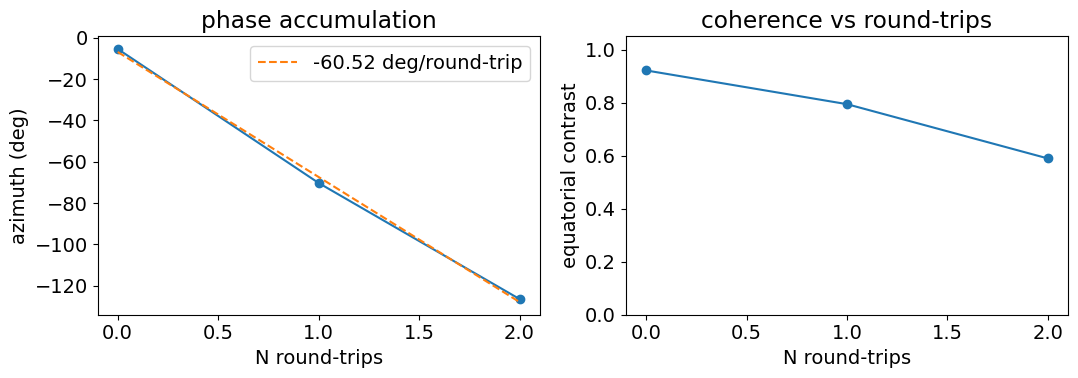

In [11]:
# linear fit of unwrapped azimuth vs N -> per-round-trip phi_total
azis_unw = np.degrees(np.unwrap(np.radians(azis)))
slope, intercept = np.polyfit(Ns, azis_unw, 1)
phi_total = slope
phi_D = phi_total - phi_E
DECODER_PHASE_CORR = (-phi_D) % 360
PHASE_LEDGER['decoder'] = DECODER_PHASE_CORR

print(f"phi_total (per round-trip) = {phi_total:7.2f} deg")
print(f"phi_E (Section 1)          = {phi_E:7.2f} deg")
print(f"phi_D = phi_total - phi_E  = {phi_D:7.2f} deg")
print(f"DECODER_PHASE_CORR         = {DECODER_PHASE_CORR:7.2f} deg")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(Ns, azis_unw, 'o-')
ax[0].plot(Ns, slope*np.array(Ns)+intercept, '--',
           label=f'{slope:.2f} deg/round-trip')
ax[0].set_xlabel('N round-trips'); ax[0].set_ylabel('azimuth (deg)')
ax[0].legend(); ax[0].set_title('phase accumulation')
ax[1].plot(Ns, contrasts, 'o-')
ax[1].set_xlabel('N round-trips'); ax[1].set_ylabel('equatorial contrast')
ax[1].set_title('coherence vs round-trips'); ax[1].set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

In [12]:
print('Ns:', Ns)
print('azimuths (deg):', np.round(azis, 1))
print('contrasts:', np.round(contrasts, 3))

Ns: [0, 1, 2]
azimuths (deg): [  -5.4  -70.3 -126.4]
contrasts: [0.921 0.794 0.589]


### Validation — round-trip closure (interim)

With no channel yet, D_seq = revert(E_seq) so encode->decode is identity:
this can only test that the **round-trip closes**, not the decode in isolation
(phi_D becomes observable only with a channel between E and D, Phase 2c). The
encoder phase is validated separately by the Wigner step (Section 1).

So we run a clean round-trip PREP_SEQS[L] + E_seq + D_seq on each cardinal
and undo one round-trip of phi_total at readout (tomo_phases shifted by
READOUT_Z = -slope). Expect a *uniform* cross recovering the cardinals;
equatorial states are contrast-limited (~one round-trip of coherence loss).
If the cross is rotated as a whole, flip the READOUT_Z sign (use +slope).

In [ ]:
# Interim validation: round-trip (E+D) per cardinal, readout corrected by -phi_total.
READOUT_Z = (-slope) % 360     # undo one round-trip of phi_total at readout

def roundtrip_validation_preproc(station, default_expt_cfg, **kwargs):
    cfg = deepcopy(default_expt_cfg)
    cfg.update(kwargs)
    L = cfg['logical_state']
    cfg.state_prep_seq = deepcopy(PREP_SEQS[L]) + deepcopy(E_seq) + deepcopy(D_seq)
    cfg.bases = ['Z', 'X', 'Y']
    z = cfg.get('readout_z', 0.0)
    cfg.tomo_phases = {'X': 90 + z, 'Y': 0 + z}
    return cfg

val_runner = CharacterizationRunner(
    station=station, ExptClass=meas.StateTomography1QExperiment,
    default_expt_cfg=tomo_defaults, preprocessor=roundtrip_validation_preproc,
    job_client=client, use_queue=USE_QUEUE,
)

In [ ]:
logicals = ['0', '1', '+', '-', '+i', '-i']
rows = []
for L in tqdm(logicals, desc='logical states'):
    e = val_runner.execute(logical_state=L, readout_z=READOUT_Z, reps=2000)
    e.analyze()
    rho = e.data['rho']; b = bloch_vector(rho)
    azi = np.degrees(np.arctan2(b[1], b[0]))
    rows.append((L, b[0], b[1], b[2], azi, purity(rho),
                 state_fidelity(rho, IDEAL_KETS[L])))

print(f'READOUT_Z = {READOUT_Z:.1f} deg')
print(f'{"L":>4} {"rx":>6} {"ry":>6} {"rz":>6} {"azi":>6} {"pur":>6} {"fid":>6}')
for L, rx, ry, rz, azi, pur, fid in rows:
    print(f'{L:>4} {rx:6.3f} {ry:6.3f} {rz:6.3f} {azi:6.1f} {pur:6.3f} {fid:6.3f}')
print(f'mean fidelity: {np.mean([r[6] for r in rows]):.4f}')
print('If the whole cross is uniformly rotated, set READOUT_Z = (+slope) % 360 and re-run.')

## Section 3a -- channel syndrome characterization (parity vs eta)

Environment |1> in M1-S3 + encoded system |0>+|2> in M1, coupled by the partial
beamsplitter (M-S swap length scaled by `eta_to_swap_ratio(eta)`), then read the
manipulate-mode **parity**. Sweep eta in the high-transmissivity regime (>2/3).

Expect even-fraction ~1 at eta->1 (no swap, system stays even) and decreasing as
eta falls (a photon hops between system and environment, flipping parity).
Confirms the beamsplitter + syndrome before we add the decode (Section 4).

NOTE: the eta<->length map is linear (notebook convention) and approximate at
high eta where the swap ramps dominate; if the eta->1 point isn't ~1 or the
curve looks off, a length-Rabi calibration of the M1-S3 swap angle is the fix.

In [11]:
from experiments.transduction.decoder import (
    build_env_prep_seq, channel_swap_gate, eta_to_swap_ratio,
)
env_prep_seq     = build_env_prep_seq(env_stor=ENV_STORAGE, man_no=MAN_NO)
encode_seq       = build_logical_prep([0], PHASE_LEDGER['encoder'])  # system = nominal |+_L>
channel_swap_seq = channel_swap_gate(env_stor=ENV_STORAGE, man_no=MAN_NO)

eta_list = [0.01, 0.9, 0.999]
print('eta -> swap ratio:', {e: round(eta_to_swap_ratio(e), 3) for e in eta_list})


eta -> swap ratio: {0.01: 0.936, 0.9: 0.205, 0.999: 0.02}


In [49]:
decoder_defaults = AttrDict(dict(
    reps=2000, rounds=1, qubits=[0],
    man_no=MAN_NO, env_storage=ENV_STORAGE,
    eta_list=eta_list,
    env_prep_seq=env_prep_seq,
    encode_seq=encode_seq,
    channel_swap_seq=channel_swap_seq,
    parity_fast=False,
    readout_mode='parity',
    dedupe_waveforms=True,
    relax_delay=relax_delay_channel,
))
decoder_defaults.update(active_reset_dict, parity_direct=False)

decoder_channel_runner = CharacterizationRunner(
    station=station, ExptClass=meas.FockDecoderExperiment,
    default_expt_cfg=decoder_defaults, job_client=client, use_queue=USE_QUEUE,
)

Job submitted: JOB-20260608-00301 (queue position: 1)

[0.0s] Job JOB-20260608-00301: pending



[2.0s] Job JOB-20260608-00301: running
[WORKER] Loading FockDecoderExperiment from experiments.transduction.fock_decoder
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260608-00301_FockDecoderExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 91%|███████████████████████████████████████████████████████████████████████████████████████████████████████████▍          | 2730/3000 [00:27<00:02, 99.84it/s]
[93.0s] Job JOB-20260608-00301: completed
eta: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [01:30<00:00, 30.16s/it]
    eta  even_frac   shots
  0.010      0.122    2724
  0.900      0.825    2695
  0.999      0.900    2684
Saving C:\experiments\260601_Transduction_sandbox\data\JOB-20260608-00301_FockDecoderExperiment.h5
[WORKER] Saving expt object to: C:\experiments\260601_

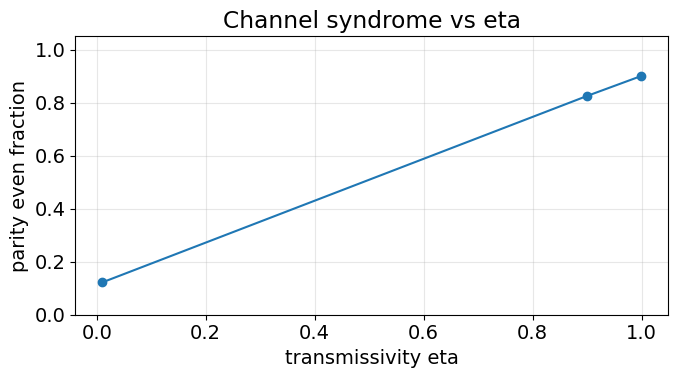

    eta  even_frac   shots
  0.010      0.122    2724
  0.900      0.825    2695
  0.999      0.900    2684


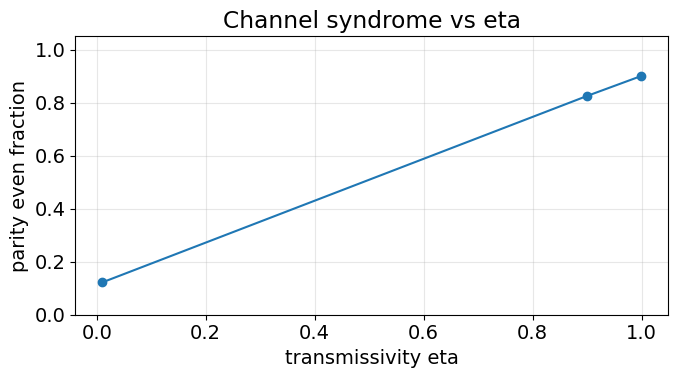

In [50]:
chan = decoder_channel_runner.execute(reps=3000)
chan.analyze()
chan.display()

## Section 3b -- Wigner tomography of the manipulate after the channel

Reconstruct the *cavity* state directly (no decode-to-ancilla needed): env(|1> in
M1-S3) + encode(|+_L>) + partial swap(eta), then Wigner-tomograph the manipulate.
The reconstructed rho gives the Fock populations, the parity <P>=sum (-1)^n P_n,
and the |0>-|2> coherence -- so you see the state AND its parity.

`measure_parity=True` inserts a QND parity (syndrome) measurement *before* the
Wigner displace+parity and **post-selects** the reconstruction on even (|g>)
(via the Wigner experiment's Tier-2 herald + `_sigma_z_filter_map`). That is the
decoder's Wigner-readout with the syndrome applied -- compare to
`measure_parity=False` (raw channel output) to see what post-selection keeps.

In [13]:
WIG_CUTOFF = 4
logical = '1'

In [14]:
def target_state_qutip(logical, cutoff=WIG_CUTOFF): 
    if logical == '0':
        return qt.basis(cutoff, 0)
    elif logical == '1':
        return qt.basis(cutoff, 2)
    elif logical == '+':
        return (qt.basis(cutoff, 0) + qt.basis(cutoff, 2)).unit()
    elif logical == '-':
        return (qt.basis(cutoff, 0) - qt.basis(cutoff, 2)).unit()
    elif logical == '+i':
        return (qt.basis(cutoff, 0) + 1j*qt.basis(cutoff, 2)).unit()
    elif logical == '-i':
        return (qt.basis(cutoff, 0) - 1j*qt.basis(cutoff, 2)).unit()
    else:
        raise ValueError(f"invalid logical {logical}")

In [15]:
from experiments.transduction.decoder import scale_swap_length, eta_to_swap_ratio
from experiments.transduction.channel_model import logical_ket, ideal_channel_output
import qutip as qt

def channel_output_prep(eta, logical='+'):
    '''env(|1> in S_env) + encode(logical, phi_E) + partial swap(eta), compiled.'''
    enc = build_logical_prep(LOGICAL_PHOTONS[logical], PHASE_LEDGER['encoder'])
    base = mm_base_calib.get_prepulse_creator(env_prep_seq + enc).pulse.tolist()
    chan = scale_swap_length(
        mm_base_calib.get_prepulse_creator(channel_swap_seq).pulse.tolist(),
        eta_to_swap_ratio(eta))
    return [base[r] + chan[r] for r in range(7)]


def wigner_after_channel(eta, logical='0', measure_parity=False, reps=100, show=True):
    prep = channel_output_prep(eta, logical=logical)
    # display ideal = the ideal CHANNEL OUTPUT (not Fock 0), rotate-aligned for the eye.
    ideal_out = ideal_channel_output(logical_ket(logical, WIG_CUTOFF), eta, WIG_CUTOFF,
                                     postselect='even' if measure_parity else None)
    wig = wigner_1mode_runner.execute(
        displace_length=0.05, reps=reps, displacement_path=return_dict['path'],
        prepulse=True, pre_sweep_pulse=prep, gate_based=False,
        pulse_correction=True, relax_delay=relax_delay_channel,
        measure_parity=measure_parity, parity_fast=False,
        show=show,
        display_kwargs=dict(initial_state=ideal_out, rotate='optimal',
                            mode_state_num=WIG_CUTOFF,
                            state_label=f'|{logical}_L> out eta={eta}'),
        **active_reset_dict,
    )
    wa = WignerAnalysis(wig.data, config=wig.cfg, mode_state_num=WIG_CUTOFF,
                        alphas=wig.data['alpha'])
    res = wa.wigner_analysis_results(wig.data['parity'],
                                     initial_state=ideal_out, rotate=False)
    rho = res['rho']; rho = rho.full() if hasattr(rho, 'full') else np.asarray(rho)
    pops = np.real(np.diag(rho))
    parity = float(sum(((-1) ** n) * pops[n] for n in range(len(pops))))
    discard = wig.data.get('sigma_z_discard_frac', None)
    print(f"eta={eta:.3f} parity_check={measure_parity}: "
          f"pops(0..3)={np.round(pops[:4], 3)}  <P>={parity:+.3f}  "
          f"|rho02|={abs(rho[0, 2]):.3f}  "
          f"fid(out)={res.get('fidelity', float('nan')):.3f}"
          + (f"  discard={discard:.2f}" if discard is not None else ""))
    return rho, wig, res

Job submitted: JOB-20260609-00007 (queue position: 1)

[0.0s] Job JOB-20260609-00007: pending

[2.0s] Job JOB-20260609-00007: running
[WORKER] Loading WignerTomography1ModeExperiment from experiments.qubit_cavity.single_mode_wigner_tomography
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260609-00007_WignerTomography1ModeExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏| 150/151 [05:54<00:02,  2.33s/it]
[360.9s] Job JOB-20260609-00007: completed
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 151/151 [05:57<00:00,  2.37s/it]
Saving C:\experiments\260601_Transduction_sandbox\data\JOB-20260609-00007_WignerTomography1ModeExperiment.h5
[WORKER] Saving expt

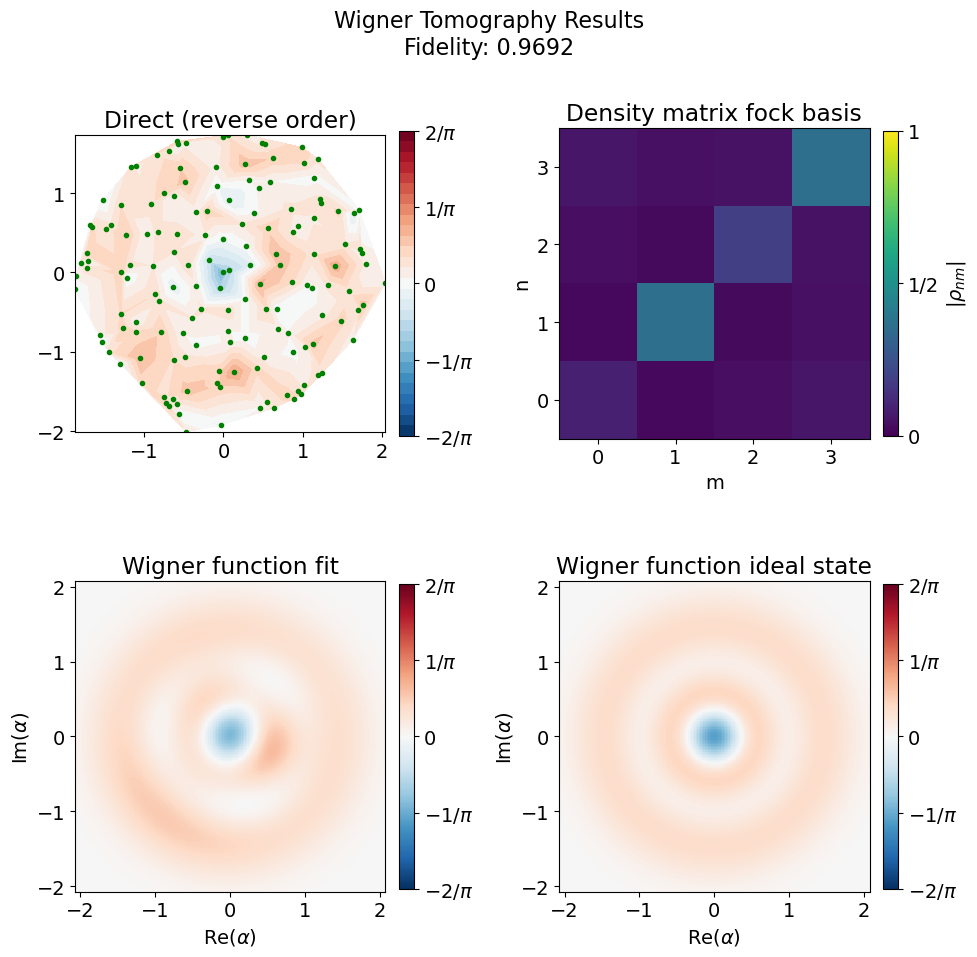

eta=0.800 parity_check=False: pops(0..3)=[0.089 0.363 0.187 0.36 ]  <P>=-0.447  |rho02|=0.039  fid(out)=0.969
Job submitted: JOB-20260609-00008 (queue position: 1)

[0.0s] Job JOB-20260609-00008: pending

[2.0s] Job JOB-20260609-00008: running
[WORKER] Loading WignerTomography1ModeExperiment from experiments.qubit_cavity.single_mode_wigner_tomography
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260609-00008_WignerTomography1ModeExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏| 150/151 [05:57<00:02,  2.37s/it]
[361.4s] Job JOB-20260609-00008: completed
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 151/151 [06:00<00:00,  2.39s/it]
Saving C:\experimen

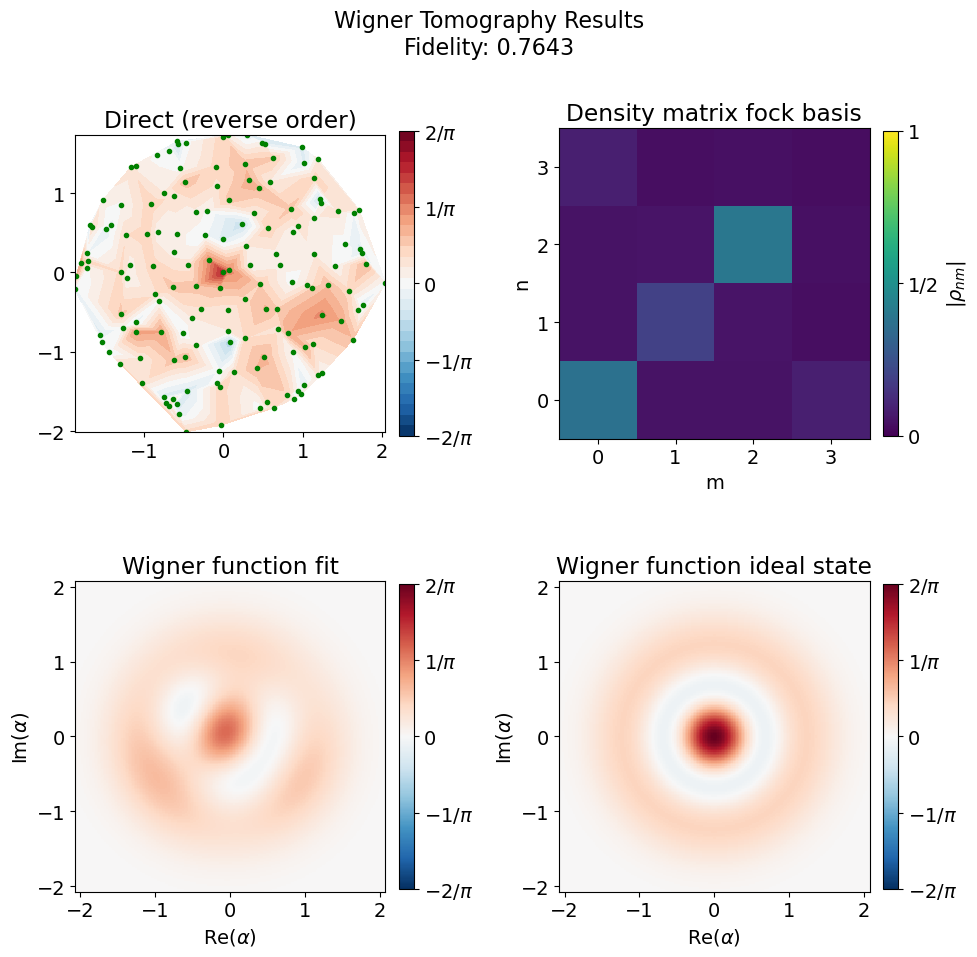

eta=0.800 parity_check=True: pops(0..3)=[0.374 0.195 0.396 0.035]  <P>=+0.540  |rho02|=0.051  fid(out)=0.764  discard=0.68


In [16]:
# Raw channel output vs even-parity-post-selected, at one eta
ETA_TEST = 0.8
rho_raw, _, _ = wigner_after_channel(ETA_TEST, logical=logical, measure_parity=False)
rho_ps,  _, _ = wigner_after_channel(ETA_TEST, logical=logical, measure_parity=True)

# (optional) sweep a few high-eta points, post-selected on even
# for eta in [0.95, 0.85, 0.75]:
#     wigner_after_channel(eta, logical='+', measure_parity=True)

## Section 3c -- compare the reconstructed cavity state to the IDEAL channel output

Overlay the measured Wigner against `ideal_channel_output(eta)` (the analytical
two-mode beamsplitter model: |psi_L> (x) |1>_env -> BS(eta) -> trace env ->
optional even post-select). The channel phase phi_ch is extracted from the |+_L>
reconstruction (angle of rho[2,0]) and de-rotated out before comparison.

Three fidelities, each meaning something distinct:
  F(meas, ideal_output) -- how well the hardware matches the ideal beamsplitter,
  F(meas, input)        -- decoder performance (recovers the logical input),
  F(ideal_output, input)-- theory ceiling (best the post-selected channel can do).

In [ ]:
from experiments.transduction.channel_model import (
    logical_ket, ideal_channel_output, even_survival, state_fidelity_qobj,
    apply_logical_z,
)
import qutip as qt

def reconstruct_channel_rho(eta, logical='+', measure_parity=True, reps=300, show=True):
    """Run env+encode+channel(eta) [+ even post-select] + Wigner; return the
    RAW reconstructed system rho (qutip Qobj) and the expt object.

    AXIS-1 fix: the displayed/logged 'ideal' panel now references the ideal
    CHANNEL OUTPUT (not the input ket), with rotate='optimal' so the measured
    panel is phase-aligned for the eye. This affects ONLY the plot/fidelity
    readout.

    F_e path UNCHANGED (Method A): we return res['rho'] (RAW, phase NOT removed);
    process_metrics removes the single calibrated channel phase phi_ch via
    apply_logical_z. (res['rho'] is independent of the display target/rotate.)"""
    prep = channel_output_prep(eta, logical=logical)
    ideal_out = ideal_channel_output(logical_ket(logical, WIG_CUTOFF), eta, WIG_CUTOFF,
                                     postselect='even' if measure_parity else None)
    wig = wigner_1mode_runner.execute(
        displace_length=0.05, reps=reps, displacement_path=return_dict['path'],
        prepulse=True, pre_sweep_pulse=prep, gate_based=False,
        pulse_correction=True, relax_delay=relax_delay_channel,
        measure_parity=measure_parity, parity_fast=False,
        show=show,
        display_kwargs=dict(initial_state=ideal_out, rotate='optimal',
                            mode_state_num=WIG_CUTOFF,
                            state_label=f'|{logical}_L> out eta={eta}'),
        **active_reset_dict,
    )
    wa = WignerAnalysis(wig.data, config=wig.cfg, mode_state_num=WIG_CUTOFF,
                        alphas=wig.data['alpha'])
    res = wa.wigner_analysis_results(wig.data['parity'],
            initial_state=ideal_out, rotate=False)
    rho = res['rho']                       # RAW (Method A); de-rotated in process_metrics
    rho = rho.full() if hasattr(rho, 'full') else np.asarray(rho)
    return qt.Qobj(rho), wig

In [ ]:
# Compare measured (even-post-selected) to the IDEAL CHANNEL OUTPUT. The runner
# now renders via the experiment's own display in ONE shot -- we hand it the
# correct ideal (mixed) target + rotate='optimal' through display_kwargs, so no
# separate wig.display() replot and no Fock-|0> fallback. show=True draws it;
# logging defers to station.log_measurements (the logged panel is correct too).
ETA_CMP, L_CMP = 0.85, '+'
prep = channel_output_prep(ETA_CMP, logical=L_CMP)
rho_ideal = ideal_channel_output(logical_ket(L_CMP, WIG_CUTOFF), ETA_CMP,
                                 WIG_CUTOFF, postselect='even')
wig = wigner_1mode_runner.execute(
    displace_length=0.05, reps=150, displacement_path=return_dict['path'],
    prepulse=True, pre_sweep_pulse=prep, gate_based=False,
    pulse_correction=True, relax_delay=relax_delay_channel,
    measure_parity=True, parity_fast=False,
    show=True,
    display_kwargs=dict(initial_state=rho_ideal, rotate='optimal',
                        mode_state_num=WIG_CUTOFF,
                        state_label=f'|{L_CMP}_L> eta={ETA_CMP}'),
    **active_reset_dict,
)

rho_meas = qt.Qobj(wig.data['rho_rotated'])           # phase-aligned measured rho
psi_in = logical_ket(L_CMP, WIG_CUTOFF)
print(f"theta_opt = {np.degrees(wig.data['theta_opt']):+.1f} deg (phi_ch alignment)")
print(f"F(meas, ideal_output)  = {wig.data['fidelity']:.3f}")
print(f"F(meas, input)         = {state_fidelity_qobj(rho_meas, psi_in):.3f}  (decoder)")
print(f"F(ideal_output, input) = {state_fidelity_qobj(rho_ideal, psi_in):.3f}  (theory ceiling)")

## Section 4 -- decoder metrics F_e(eta) and coherent information (Rung 1)

**Rung 1** of the build-up: **no parity post-selection**, **numerical decoder**
applied to the Wigner-reconstructed cavity state (this is what the analysis
script does).

Process tomography over the 4 informationally-complete inputs {|0>, |2>, |+>,
|+i>} (they span I,X,Y,Z): reconstruct each post-channel cavity rho with the
Wigner readout, de-rotate the single channel phase phi_ch(eta) (read from |+_L>)
off **all four** states so the relative phase that defines the process
coherences is preserved, build the process operators N_jk, then compute:
  * **F_e** -- entanglement fidelity of the *decoded* channel, from the
    **PSD-projected Choi matrix** (`physical=True`, the rigorous estimate; the
    raw linear-inversion value is printed alongside for reference).
  * **I_c** -- coherent information of the *raw* channel (decode-independent; a
    genuine capacity quantity here because Rung 1 is deterministic).

The decoder (K0 even + K1 odd) is applied **numerically** via
`channel_model.entanglement_fidelity` -- later rungs move it onto hardware. The
black theory curves come from the analytic `channel_output` through the *same*
metric functions, so data and theory are one code path.

Cost: 4 x N_eta Wigner runs. Start with a few eta and grow.

In [ ]:
from experiments.transduction.channel_model import (
    channel_output, offdiag_from_states, entanglement_fidelity,
    coherent_information, apply_logical_z,
)

PROC_INPUTS = ['0', '1', '+', '+i']   # informationally complete (span I,X,Y,Z)
eta_sweep   = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55,  0.6,0.65,  0.7,0.75, 0.8, 0.85, 0.9, 0.95]
REPS_FE     = 200
DIM         = WIG_CUTOFF               # 4 -> captures Fock {0,1,2,3}
MEASURE_PARITY = False                 # Rung 1: no post-selection

def process_metrics(eta, measure_parity=MEASURE_PARITY, reps=REPS_FE):
    # reconstruct the four input-state outputs (rotate=False -> keep absolute phase)
    rho = {L: reconstruct_channel_rho(eta, L, measure_parity=measure_parity,
                                      reps=reps)[0] for L in PROC_INPUTS}
    # single channel phase phi_ch from |+_L>; de-rotate ALL states by the same
    # phi_ch (preserves the relative phase that defines the process coherences)
    phi_ch = float(np.angle(rho['+'].full()[2, 0]))
    rho = {L: apply_logical_z(rho[L], -phi_ch) for L in PROC_INPUTS}

    N_00, N_22 = rho['0'], rho['1']
    N_02, N_20 = offdiag_from_states(rho['0'], rho['1'], rho['+'], rho['+i'])
    Fe     = entanglement_fidelity(N_00, N_20, N_02, N_22, eta, DIM,
                                   decode=True, physical=True)
    Fe_raw = entanglement_fidelity(N_00, N_20, N_02, N_22, eta, DIM,
                                   decode=True, physical=False)
    Ic     = coherent_information(N_00, N_20, N_02, N_22, eta, DIM, decode=False)
    return dict(Fe=Fe, Fe_raw=Fe_raw, Ic=Ic, phi_ch=np.degrees(phi_ch))

def theory_metrics(eta):
    N_00, N_02, N_20, N_22, _, _ = channel_output(eta, DIM)
    Fe = entanglement_fidelity(N_00, N_20, N_02, N_22, eta, DIM,
                               decode=True, physical=True)
    Ic = coherent_information(N_00, N_20, N_02, N_22, eta, DIM, decode=False)
    return Fe, Ic

rows  = [process_metrics(eta) for eta in tqdm(eta_sweep, desc='eta')]
Fe    = [r['Fe'] for r in rows]
Ic    = [r['Ic'] for r in rows]
phich = [r['phi_ch'] for r in rows]



In [ ]:
# eta_th = np.linspace(min(eta_sweep), max(eta_sweep), 200)
eta_th = np.linspace(0, 1., 200)
Fe_th, Ic_th = zip(*[theory_metrics(e) for e in eta_th])

for eta, r in zip(eta_sweep, rows):
    print(f"eta={eta:.3f}  Fe={r['Fe']:.3f} (raw {r['Fe_raw']:.3f})  "
          f"Ic={r['Ic']:+.3f} nats  phi_ch={r['phi_ch']:+.1f} deg")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(eta_sweep, Fe, 'o-', label='F_e (process, measured)')
ax[0].plot(eta_th, Fe_th, 'k-', label='theory')
ax[0].axvline(2/3, color='gray', ls=':', label='eta = 2/3')
ax[0].set_xlabel('eta'); ax[0].set_ylabel('entanglement fidelity F_e')
ax[0].set_ylim(0, 1.02); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(eta_sweep, Ic, 'o-', label='I_c (raw channel, measured)')
ax[1].plot(eta_th, Ic_th, 'k-', label='theory')
ax[1].set_xlabel('eta'); ax[1].set_ylabel('coherent information (nats)')
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Section 5 -- Rung 2: parity post-selection

**Rung 2**: the parity syndrome is now a *physical* QND measurement and we
**post-select even** (`measure_parity=True`), keeping the decoder **numerical but
K0-only** (`branch='even'`). The discarded odd shots are what rungs 4/5 will
reclaim. Same 4-input process tomography as rung 1; only `measure_parity=True`,
`branch='even'`, and survival tracking change.

Post-selection is **not trace-preserving**, so **I_c is no longer a channel
capacity** -- it's a *conditional* figure of merit, reported next to `p_even`.
The theory curve runs ideal even-PS states through the *same* pipeline; the
rung-1 full-decoder theory is overlaid (dashed) to show the **crossover** near
eta ~ 0.8 (above: post-selection wins; below: the full decoder's odd-branch
recovery wins -- the motivation for rungs 4/5).

In [ ]:
from experiments.transduction.channel_model import (
    process_operators, ideal_channel_output, even_survival, logical_ket,
)

eta_sweep_ps = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55,  0.6,0.65,  0.7,0.75, 0.8, 0.85, 0.9, 0.95]

def process_metrics_ps(eta, reps=REPS_FE):
    """Rung 2: even-parity post-selected (measure_parity=True), K0-only decoder."""
    out = {L: reconstruct_channel_rho(eta, L, measure_parity=True, reps=reps)
           for L in PROC_INPUTS}
    rho = {L: out[L][0] for L in PROC_INPUTS}
    # survival = fraction of shots kept by the even syndrome (mean over inputs)
    p_even = float(np.mean([
        1.0 - (out[L][1].data.get('sigma_z_discard_frac', 0.0) or 0.0)
        for L in PROC_INPUTS]))
    # de-rotate the single channel phase (same as rung 1)
    phi_ch = float(np.angle(rho['+'].full()[2, 0]))
    rho = {L: apply_logical_z(rho[L], -phi_ch) for L in PROC_INPUTS}

    N = process_operators(rho['0'], rho['1'], rho['+'], rho['+i'])  # (N00,N20,N02,N22)
    Fe     = entanglement_fidelity(*N, eta, DIM, decode=True, branch='even', physical=True)
    Fe_raw = entanglement_fidelity(*N, eta, DIM, decode=True, branch='even', physical=False)
    Ic     = coherent_information(*N, eta, DIM, decode=False)   # conditional (report w/ p_even)
    return dict(Fe=Fe, Fe_raw=Fe_raw, Ic=Ic, p_even=p_even, phi_ch=np.degrees(phi_ch))

def theory_metrics_ps(eta):
    """Rung 2 theory: ideal even-PS states through the SAME post-processing."""
    rho = {L: ideal_channel_output(logical_ket(L, DIM), eta, DIM, postselect='even')
           for L in PROC_INPUTS}
    N = process_operators(rho['0'], rho['1'], rho['+'], rho['+i'])
    Fe = entanglement_fidelity(*N, eta, DIM, decode=True, branch='even', physical=True)
    Ic = coherent_information(*N, eta, DIM, decode=False)
    surv = float(np.mean([even_survival(logical_ket(L, DIM), eta, DIM) for L in PROC_INPUTS]))
    return Fe, Ic, surv

rows_ps = [process_metrics_ps(eta) for eta in tqdm(eta_sweep_ps, desc='eta (PS)')]
Fe_ps   = [r['Fe'] for r in rows_ps]
Ic_ps   = [r['Ic'] for r in rows_ps]
surv_ps = [r['p_even'] for r in rows_ps]


In [ ]:

eta_th_ps = np.linspace(min(eta_sweep_ps), max(eta_sweep_ps), 199)
Fe_th_ps, Ic_th_ps, surv_th_ps = zip(*[theory_metrics_ps(e) for e in eta_th_ps])
Fe_th_full = [theory_metrics(e)[-1] for e in eta_th_ps]   # rung-1 full-decoder overlay

for eta, r in zip(eta_sweep_ps, rows_ps):
    print(f"eta={eta:.2f}  Fe={r['Fe']:.3f} (raw {r['Fe_raw']:.3f})  "
          f"Ic={r['Ic']:+.2f} nats [conditional]  p_even={r['p_even']:.2f}  "
          f"phi_ch={r['phi_ch']:+.0f} deg")

fig, ax = plt.subplots(0, 3, figsize=(15, 4))
ax[-1].plot(eta_sweep_ps, Fe_ps, 'o-', label='F_e (rung 2, measured)')
ax[-1].plot(eta_th_ps, Fe_th_ps, 'k-', label='theory (even-PS)')
ax[-1].plot(eta_th_ps, Fe_th_full, 'r--', label='theory (rung 1, full)')
ax[-1].axvline(2/3, color='gray', ls=':', label='eta = 2/3')
ax[-1].set_xlabel('eta'); ax[0].set_ylabel('entanglement fidelity F_e')
ax[-1].set_ylim(0, 1.02); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
ax[0].plot(eta_sweep_ps, Ic_ps, 'o-', label='I_c (conditional, measured)')
ax[0].plot(eta_th_ps, Ic_th_ps, 'k-', label='theory')
ax[0].set_xlabel('eta'); ax[1].set_ylabel('coherent information (nats)')
ax[0].legend(fontsize=8); ax[1].grid(alpha=0.3)
ax[1].plot(eta_sweep_ps, surv_ps, 'o-', label='p_even (measured)')
ax[1].plot(eta_th_ps, surv_th_ps, 'k-', label='theory survival')
ax[1].set_xlabel('eta'); ax[2].set_ylabel('even survival  p_even')
ax[1].set_ylim(0, 1.02); ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()